Libraries imported successfully.
Training shape: (5634, 47)
Testing shape : (1409, 47)
X_train: (5634, 46)
X_test : (1409, 46)
Training target distribution:


Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


Testing target distribution:


Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Models created:
- Logistic Regression
- Random Forest
- Gradient Boosting

Training Logistic Regression...
Logistic Regression training completed.

Training Random Forest...
Random Forest training completed.

Training Gradient Boosting...
Gradient Boosting training completed.


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.739,0.505,0.802,0.620,0.846
2,Gradient Boosting,0.798,0.656,0.505,0.571,0.844
1,Random Forest,0.767,0.544,0.759,0.634,0.840


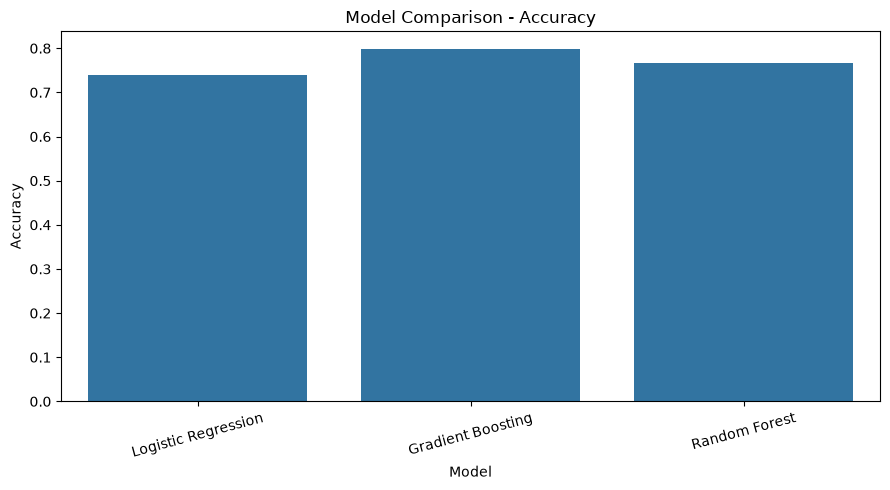

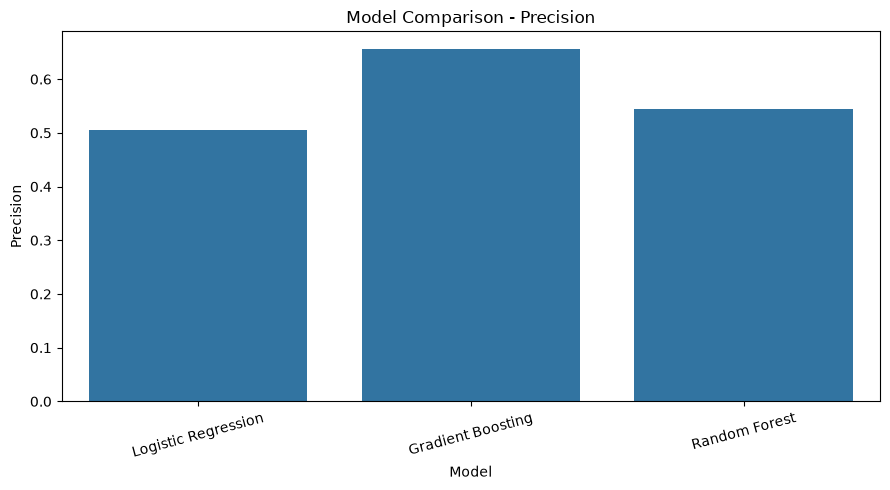

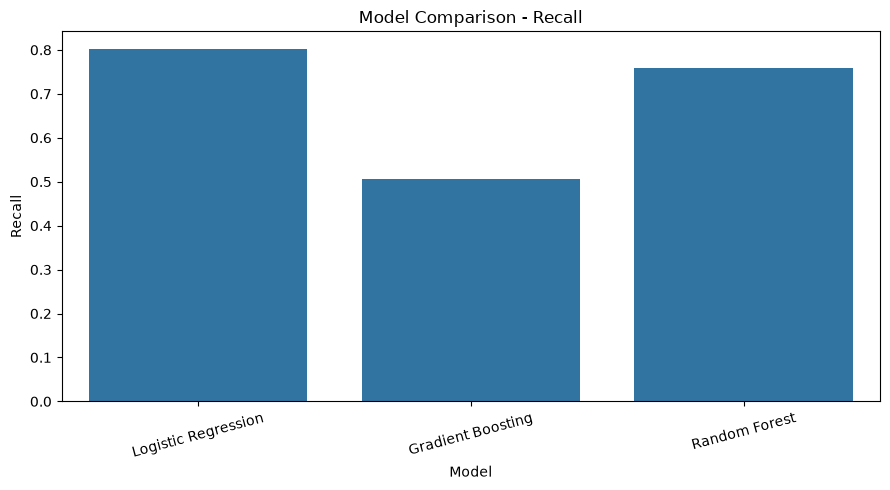

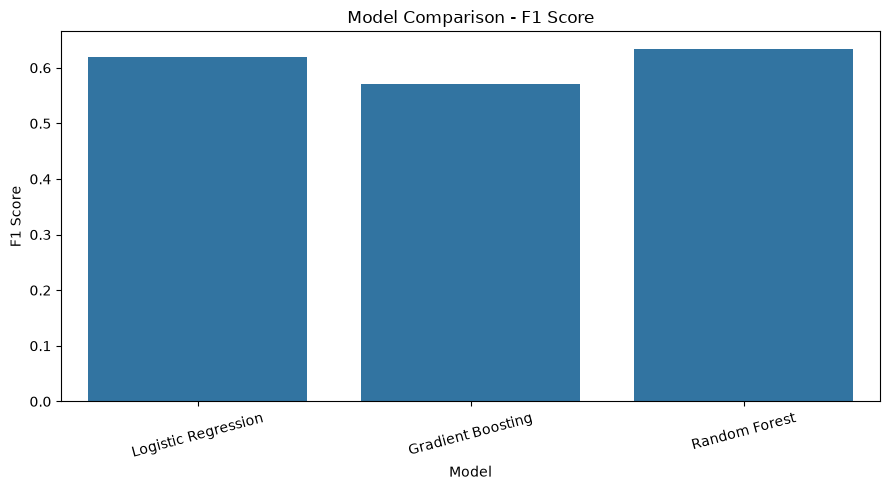

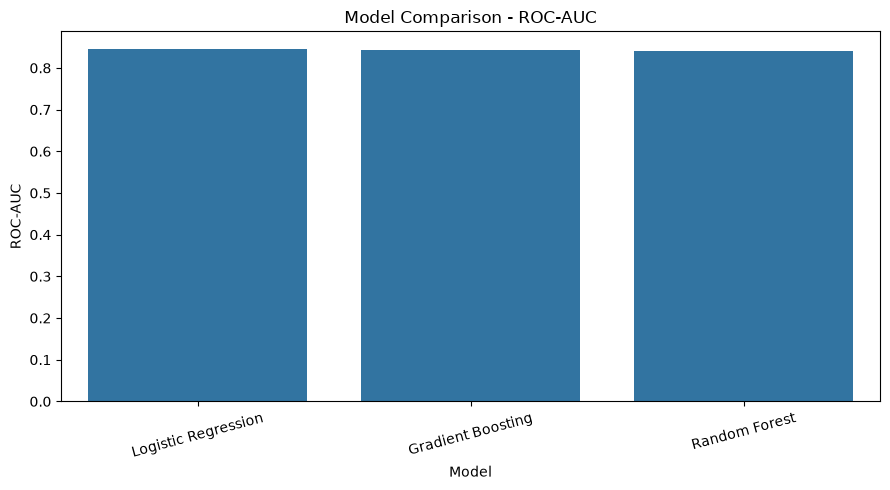

Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Random Forest
              precision    recall  f1-score   support

      Stayed       0.90      0.77      0.83      1035
     Churned       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.87      1035
     Churned       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.7

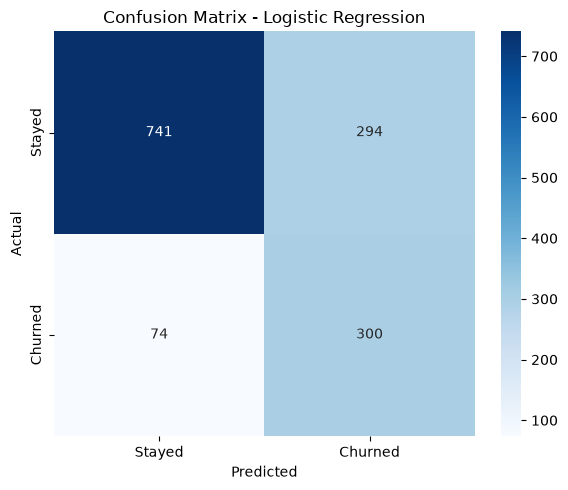

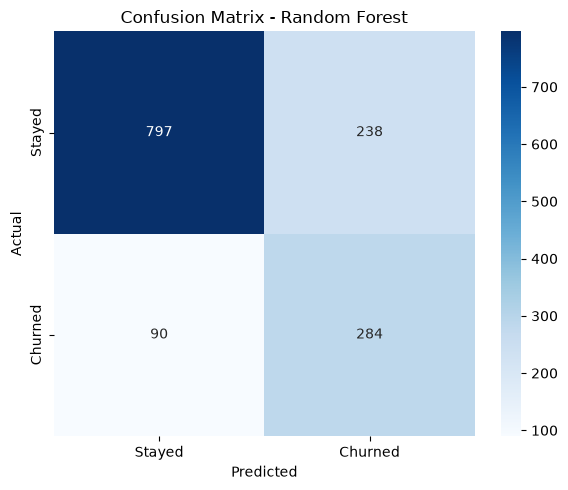

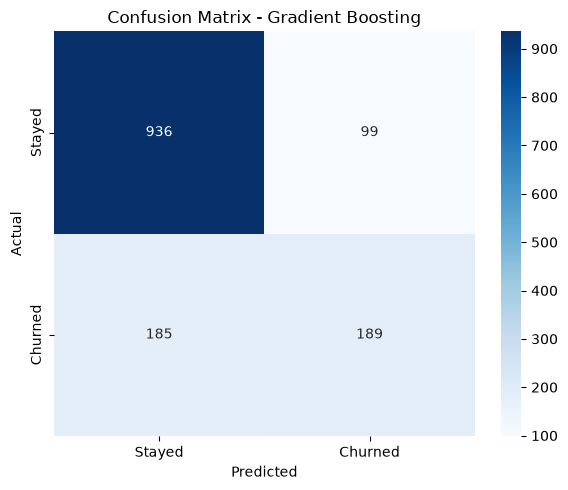

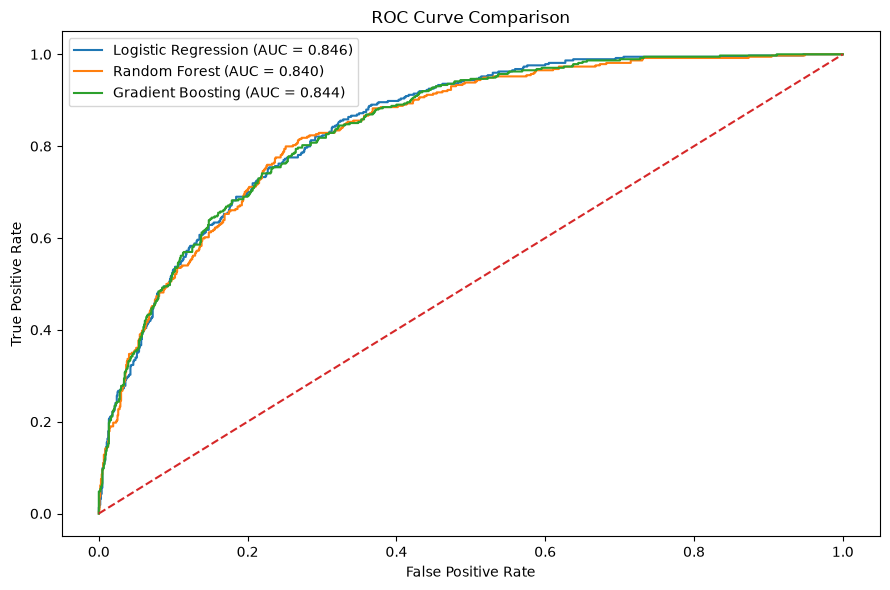

Selected model based on ROC-AUC:
Logistic Regression

Top features - Random Forest


,Feature,Importance
22,MonthToMonth,0.105690
3,tenure,0.085839
7,TotalCharges,0.080127
8,TenureYears,0.077405
12,ChargePerTenureMonth,0.062744
11,EstimatedAnnualCharges,0.061411
6,MonthlyCharges,0.060896
42,Contract_Two year,0.058702
27,InternetService_Fiber optic,0.051939
44,PaymentMethod_Electronic check,0.027031


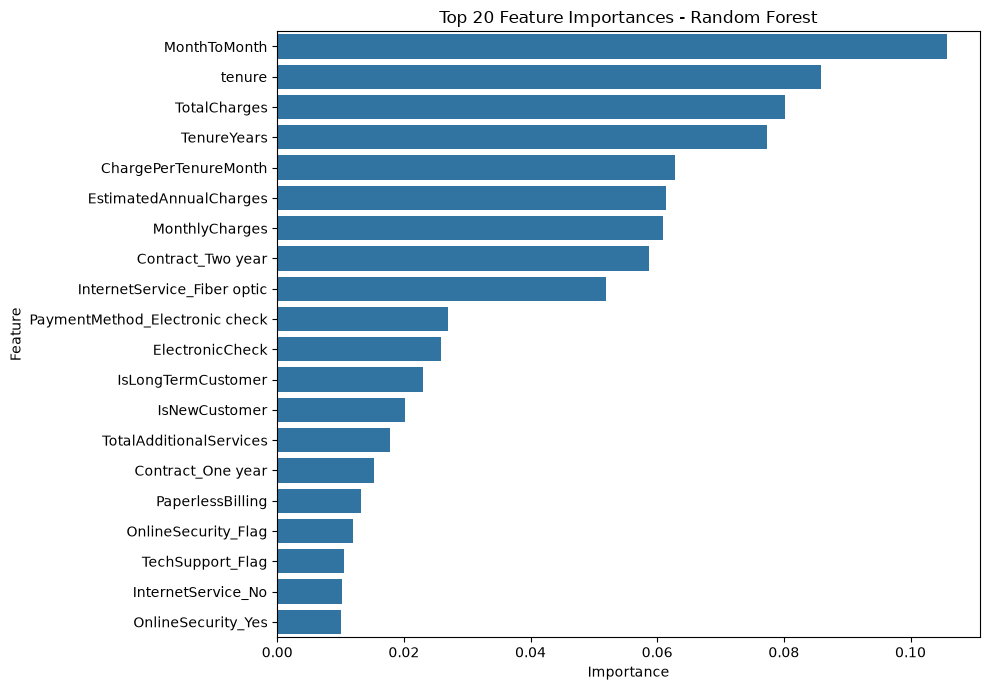


Top features - Gradient Boosting


,Feature,Importance
22,MonthToMonth,0.405310
27,InternetService_Fiber optic,0.107473
3,tenure,0.082366
7,TotalCharges,0.067460
8,TenureYears,0.066005
12,ChargePerTenureMonth,0.045743
44,PaymentMethod_Electronic check,0.029209
23,ElectronicCheck,0.027505
11,EstimatedAnnualCharges,0.023345
5,PaperlessBilling,0.019677


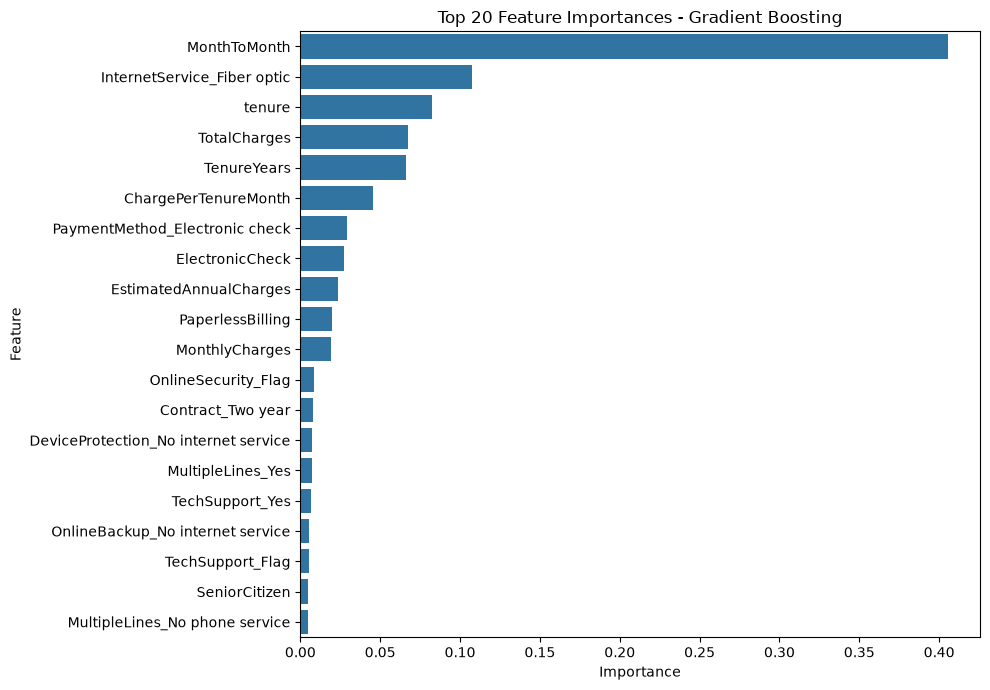

,Feature,Coefficient,AbsoluteCoefficient
27,InternetService_Fiber optic,1.364357,1.364357
42,Contract_Two year,-1.058837,1.058837
9,IsNewCustomer,0.701376,0.701376
22,MonthToMonth,0.520165,0.520165
4,PhoneService,-0.428204,0.428204
26,MultipleLines_Yes,0.400987,0.400987
8,TenureYears,-0.349087,0.349087
3,tenure,-0.349087,0.349087
5,PaperlessBilling,0.345203,0.345203
25,MultipleLines_No phone service,-0.320891,0.320891


,Churn,ChurnProbability,RiskLevel
0,0,0.112186,Low
1,0,0.844996,High
2,0,0.138380,Low
3,0,0.605859,High
4,0,0.069333,Low
5,0,0.780563,High
6,0,0.659008,High
7,0,0.256773,Low
8,0,0.014998,Low
9,1,0.569235,Medium


RiskLevel
Low       609
High      475
Medium    325
Name: count, dtype: int64

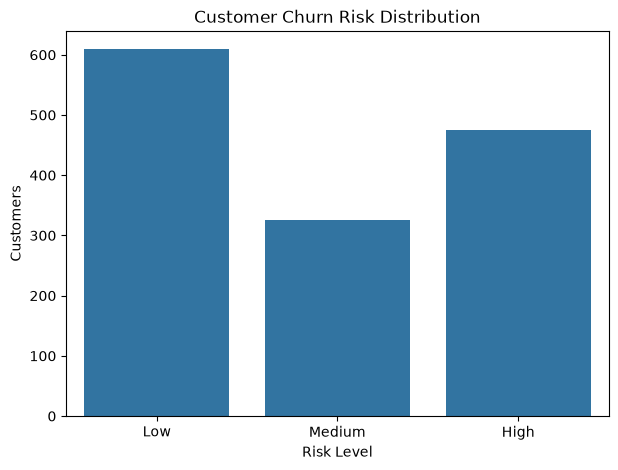

Model comparison saved.
Risk predictions saved.


In [1]:
# ============================================================
# CUSTOMER CHURN INTELLIGENCE
# 04 - MODEL TRAINING & EVALUATION
# ============================================================

# %% [markdown]
# # Customer Churn Intelligence
# ## 04. Machine Learning Model Training & Evaluation
#
# Models:
# 1. Logistic Regression
# 2. Random Forest
# 3. Gradient Boosting
#
# Evaluation:
# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - ROC-AUC
# - Confusion Matrix
#
# Note:
# For churn prediction, recall and ROC-AUC are particularly useful
# because missing a customer who is likely to churn can be costly.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("Libraries imported successfully.")

# %% [markdown]
# ## 1. Load Training and Testing Data

# %%
train_path = "../data/processed/train.csv"
test_path = "../data/processed/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

# %% [markdown]
# ## 2. Separate Features and Target

# %%
X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# %% [markdown]
# ## 3. Verify Target Distribution

# %%
print("Training target distribution:")
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution:")
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# %% [markdown]
# ## 4. Define Models

# %%
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Models created:")
for name in models:
    print("-", name)

# %% [markdown]
# ## 5. Train Models

# %%
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    print(f"{name} training completed.")

# %% [markdown]
# ## 6. Evaluate Models

# %%
results = []

predictions = {}
probabilities = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    y_probability = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_probability

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_probability
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

# %% [markdown]
# ## 7. Visualize Model Comparison

# %%
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for metric in metrics:

    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=results_df,
        x="Model",
        y=metric
    )

    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 8. Classification Reports

# %%
for name in trained_models:

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["Stayed", "Churned"],
            zero_division=0
        )
    )

# %% [markdown]
# ## 9. Confusion Matrices

# %%
for name in trained_models:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Stayed", "Churned"],
        yticklabels=["Stayed", "Churned"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 10. ROC Curves

# %%
plt.figure(figsize=(9, 6))

for name in trained_models:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    auc = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 11. Select a Model for Deployment
#
# We select based on the evaluation results rather than assuming
# a model is best beforehand.

# %%
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("Selected model based on ROC-AUC:")
print(best_model_name)

# %% [markdown]
# ## 12. Feature Importance
#
# Random Forest and Gradient Boosting provide feature importance.
#
# Logistic Regression provides coefficients.

# %%
for name in [
    "Random Forest",
    "Gradient Boosting"
]:

    model = trained_models[name]

    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    ).head(20)

    print(f"\nTop features - {name}")

    display(importance)

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Top 20 Feature Importances - {name}"
    )

    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 13. Logistic Regression Coefficients

# %%
logistic_model = trained_models[
    "Logistic Regression"
]

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["AbsoluteCoefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

display(
    coefficients.head(20)
)

# %% [markdown]
# ## 14. Identify High-Risk Customers
#
# Use the selected model to generate churn probabilities.

# %%
churn_probability = best_model.predict_proba(
    X_test
)[:, 1]

risk_df = test_df.copy()

risk_df["ChurnProbability"] = churn_probability

risk_df["RiskLevel"] = pd.cut(
    risk_df["ChurnProbability"],
    bins=[0, 0.30, 0.60, 1.0],
    labels=[
        "Low",
        "Medium",
        "High"
    ],
    include_lowest=True
)

display(
    risk_df[
        [
            "Churn",
            "ChurnProbability",
            "RiskLevel"
        ]
    ].head(20)
)

# %% [markdown]
# ## 15. Risk Distribution

# %%
risk_distribution = (
    risk_df["RiskLevel"]
    .value_counts()
)

display(risk_distribution)

# %%
plt.figure(figsize=(7, 5))

sns.countplot(
    data=risk_df,
    x="RiskLevel",
    order=["Low", "Medium", "High"]
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Customers")

plt.show()

# %% [markdown]
# ## 16. Save Model Results

# %%
results_df.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

# %% [markdown]
# ## 17. Save High-Risk Predictions

# %%
risk_df.to_csv(
    "../data/processed/churn_risk_predictions.csv",
    index=False
)

print("Risk predictions saved.")

# %% [markdown]
# # Model Training Completed
#
# We have:
# - Trained multiple ML models
# - Compared performance
# - Generated classification reports
# - Created confusion matrices
# - Compared ROC curves
# - Analyzed feature importance
# - Generated churn probabilities
# - Created customer risk levels
#
# Next:
# Save the production model → Build prediction API → Build dashboard